In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from pandas import read_csv, DataFrame, concat

from numpy import arange, full, nan, size, shape, pi

from seaborn import heatmap

from os import path

from qiskit.circuit.library import z_feature_map, unitary_overlap, zz_feature_map

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from qiskit.circuit.library import ZZFeatureMap
from qiskit import QuantumCircuit

import qnexus as qnx

from pytket.extensions.qiskit import qiskit_to_tk


DATA_PATH = path.join('..', 'data', "water_potability.csv")
RANDOM_SEED = 42
NUMBER_MUESTRAS_ENTRENAMIENTO = 8
USAR_MATRICES_PRECOMPUTADAS = True

# Get data

In [14]:
data = read_csv(DATA_PATH)

data = data.dropna() # hay que limpiar los NaN, si no el normalizar no tiene sentido

data = data.sample(frac=1,\
                   random_state=RANDOM_SEED)

potable_data = data.loc[data['Potability']==1]

unpotable_data = data.loc[data['Potability']==0]

muestras = int((NUMBER_MUESTRAS_ENTRENAMIENTO/.8)/2)

data = concat([potable_data.iloc[0:muestras], \
               unpotable_data.iloc[0:muestras]])


data = data.sample(frac = 1, \
                   random_state=RANDOM_SEED)

'''

Hay que ver si se ponen nuevas features

'''

'''
El documento dice

Imputar valores faltantes (pH: 491 NaN; Sulfato: 781 NaN; Trihalometanos: 162 NaN) por mediana por clase.

Pero no sé si hay que hacer caso a eso xd

'''
potability = data["Potability"]

data = data.drop("Potability", axis = 1) # quitar potabilidad

# Pre-proccess data

In [15]:
data_train, data_test, potability_train, potability_test = \
train_test_split(data, potability, test_size=.2, random_state=RANDOM_SEED)



#scaler = MinMaxScaler(feature_range=(0, 2 * pi))

scaler = StandardScaler()

data_train_scaled = scaler.fit_transform(data_train)
data_test_scaled = scaler.transform(data_test)

pca = PCA(n_components = 4, random_state=RANDOM_SEED)

data_train_scaled = pca.fit_transform(data_train_scaled)

data_test_scaled = pca.transform(data_test_scaled)

# SVM

In [16]:
scores = ["precision", "recall"]

'''
Por si quiero quemar la compu

gamma = ["scale", "auto"]

gamma.extend(list(arange(start = .01, stop = 1, step = .005)))

C = arange(start=1, stop= 1000, step=100)

'''

C = [1, 10]

gamma = ["scale", "auto", .1]


tuned_parameters = [
    {"kernel": ["rbf"], "gamma": gamma, "C":C}
]

def refit_strategy(cv_results):
	
    cv_results_ = DataFrame(cv_results)

    best_index = cv_results_["mean_test_recall"].idxmax()

    return best_index

grid_search = GridSearchCV(
    SVC(), tuned_parameters, scoring=scores, refit=refit_strategy, cv=5, n_jobs=-1
)

grid_search.fit(data_train_scaled, potability_train)

c:\Users\maxru\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 10], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'recall']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function ref...002E094F349E0>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls

# Test

In [17]:
potability_prediction = grid_search.predict(data_test_scaled)

print(f'Confusion matrix: \n {confusion_matrix(potability_test, potability_prediction)}\n')
print(f'Accuracy = {accuracy_score(potability_test, potability_prediction):.2f}')
print(f'Clasification report: \n {classification_report(potability_test, \
potability_prediction, target_names=['Non-Potable' , 'Potable'])}')

Confusion matrix: 
 [[0 0]
 [2 0]]

Accuracy = 0.00
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.00      0.00      0.00       0.0
     Potable       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\maxru\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maxru\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maxru\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [18]:
results = DataFrame(grid_search.cv_results_)


results.to_csv("laMambaNegra.csv")

print(f'Best params: {grid_search.best_params_}')

results[
    [
        "param_C",
        "param_gamma",
        "mean_test_precision",
        "mean_test_recall",
    ]
]

Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


,param_C,param_gamma,mean_test_precision,mean_test_recall
0,1,scale,0.0,0.0
1,1,auto,0.0,0.0
2,1,0.1,0.0,0.0
3,10,scale,0.0,0.0
4,10,auto,0.0,0.0
5,10,0.1,0.0,0.0


<Axes: >

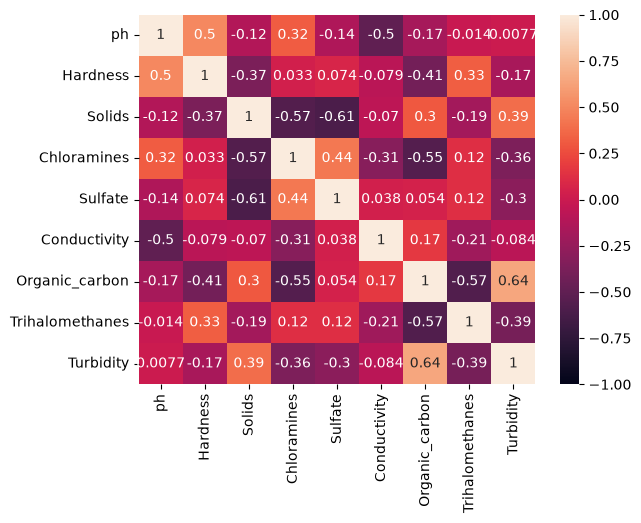

In [19]:
heatmap(data.corr(), \
			 annot=True, \
			 robust=True, \
			 vmin= -1, \
			 vmax= 1)

# QSVM

# Nexus Login

In [20]:
qnx.login()

Already logged in. Tokens are valid.


# Create project

In [21]:
project = qnx.projects.get_or_create(
    name="Water Potability QSVM"
)

qnx.context.set_active_project(project)

# Define Emulator

In [22]:
backend = qnx.QuantinuumConfig(
    device_name="H2-Emulator"
)

# Quantum Kernel

In [23]:
fm = z_feature_map(feature_dimension=data_train_scaled.shape[1])

train_size = data_train_scaled.shape[0]

kernel_matrix = np.eye(train_size)

num_shots = 100

programs = []
pairs = []

# 1) CREATE ALL CIRCUITS
for x1 in range(train_size):
    for x2 in range(x1 + 1, train_size):

        unitary1 = fm.assign_parameters(data_train_scaled[x1])
        unitary2 = fm.assign_parameters(data_train_scaled[x2])

        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        tk_overlap = qiskit_to_tk(overlap_circ)

        program = qnx.circuits.upload(
            circuit=tk_overlap,
            name=f"kernel_{x1}_{x2}",
        )

        programs.append(program)
        pairs.append((x1, x2))


# 2) COMPILE ONCE
compile_job = qnx.start_compile_job(
    programs=programs,
    backend_config=backend,
    optimisation_level=2,
    name="compile_kernel_matrix",
)

qnx.jobs.wait_for(compile_job)

compiled = [
    result.get_output()
    for result in qnx.jobs.results(compile_job)
]


# 3) EXECUTE ONCE
execute_job = qnx.start_execute_job(
    programs=compiled,
    n_shots=[num_shots] * len(compiled),
    backend_config=backend,
    name="execute_kernel_matrix",
)

qnx.jobs.wait_for(execute_job)

results = qnx.jobs.results(execute_job)


# 4) FILL KERNEL MATRIX
for pair, result in zip(pairs, results):

    distribution = result.download_result().get_distribution()

    prob_zero = distribution.get((0,0,0,0),0)

    x1, x2 = pair

    kernel_matrix[x1,x2] = prob_zero
    kernel_matrix[x2,x1] = prob_zero


# diagonal = 1
for i in range(train_size):
    kernel_matrix[i,i] = 1

C:\Users\maxru\AppData\Local\Temp\ipykernel_8620\444951887.py:65: DeprecationWarning: The `BackendResult.get_distribution()` method is deprecated: please use `get_empirical_distribution()` or `get_probability_distribution()` instead.
  distribution = result.download_result().get_distribution()


# Quantum data Matrix 

In [ ]:
test_size = shape(data_test_scaled)[0]

'''
La matriz de prueba tiene forma test x train,
porque contiene la relación entre datos nuevos y datos de entrenamiento
'''

test_matrix = np.eye(train_size)

programs = []
pairs = []


# 1) CREATE ALL TEST CIRCUITS
for x1 in range(test_size):
    for x2 in range(train_size):

        unitary1 = fm.assign_parameters(data_test_scaled[x1])
        unitary2 = fm.assign_parameters(data_train_scaled[x2])

        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        tk_overlap = qiskit_to_tk(overlap_circ)

        program = qnx.circuits.upload(
            circuit=tk_overlap,
            name=f"test_{x1}_{x2}",
        )

        programs.append(program)
        pairs.append((x1, x2))


# 2) COMPILE ONCE
compile_job = qnx.start_compile_job(
    programs=programs,
    backend_config=backend,
    optimisation_level=2,
    name="compile_test_matrix",
)

qnx.jobs.wait_for(compile_job)

compiled = [
    result.get_output()
    for result in qnx.jobs.results(compile_job)
]


# 3) EXECUTE ONCE
execute_job = qnx.start_execute_job(
    programs=compiled,
    n_shots=[num_shots] * len(compiled),
    backend_config=backend,
    name="execute_test_matrix",
)

qnx.jobs.wait_for(execute_job)

results = qnx.jobs.results(execute_job)


# 4) FILL TEST MATRIX
for pair, result in zip(pairs, results):

    distribution = result.download_result().get_distribution()

    prob_zero = distribution.get((0,0,0,0), 0)

    x1, x2 = pair

    test_matrix[x1, x2] = prob_zero


print("Pairs:", len(pairs))
print("Expected:", test_size * train_size)
print(test_matrix.shape)

C:\Users\maxru\AppData\Local\Temp\ipykernel_8620\2675350664.py:67: DeprecationWarning: The `BackendResult.get_distribution()` method is deprecated: please use `get_empirical_distribution()` or `get_probability_distribution()` instead.
  distribution = result.download_result().get_distribution()


# Test QSVM

In [25]:
qsvm = SVC(kernel='precomputed')

qsvm.fit(kernel_matrix, potability_train)

potability_prediction = qsvm.predict(test_matrix)


print(f'Confusion matrix: \n {confusion_matrix(potability_test, potability_prediction)}\n')
print(f'Accuracy = {accuracy_score(potability_test, potability_prediction):.2f}')
print(f'Clasification report: \n {classification_report(potability_test, \
potability_prediction, target_names=['Non-Potable' , 'Potable'])}')


ValueError: Found input variables with inconsistent numbers of samples: [2, 8, 2]

In [ ]:
import numpy as np
off_diag = kernel_matrix[~np.eye(kernel_matrix.shape[0], dtype=bool)]
print(f"Media: {off_diag.mean():.4f}, Std: {off_diag.std():.4f}")
print(f"Min: {off_diag.min():.4f}, Max: {off_diag.max():.4f}")
print(potability_prediction)
kernel_matrix

In [ ]:
print(potability_prediction)
print(potability_test)